# Exercise for Graph V -- Automatic High-Low Game

## Your task:

Make the graph on the right! You need to implement an Automatic Higher or Lower Game.

Set the bounds to between 1 to 20. The Graph has to keep guessing (max number of guesses is 7) where if the guess is correct, then it stops, but if not we keep looping until we hit the max limit of 7.

Each time a number is guessed, the hint node should say higher or lower and the graph should account for this information and guess the next guess accordingly.

### Input:

{
    "player_name": "Student",
    "guesses": [],
    "attempts": 0,
    "lower_bound": 1,
    "upper_bound": 20
}

### Hint:
It will need to adjust its bounds after every guess based on the hint provided by the hint node.

In [21]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [22]:
class StateAgent(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    correct_number: int
    message: str

In [23]:
def start_the_game(state: StateAgent) -> StateAgent:
    """
    Basic settings to start the automatic high-low game
    """

    state["player_name"] = f"Welcome to the High-Low Game, {state["player_name"]}"

    state["guesses"] = []
    state["attempts"] = 0
    state["lower_bound"] = 1
    state["upper_bound"] = 20
    # the number to be guessed to win the game 
    state["correct_number"] = random.randint(state["lower_bound"], state["upper_bound"])
    
    return state

In [24]:
def guess_the_number(state: StateAgent) -> StateAgent:
    """
    Node that guesses the right number in a loop (up to the attempt limit of 7 times)
    """
    ## Stop if the attempt limit(7 times) reaches
    if state["attempts"] >= 8:
        return state

    ### prevent duplicate numbers
    while True:
        guess = random.randint(state["lower_bound"], state["upper_bound"])
        if guess not in state["guesses"]:
            break

    ### Append the guess if the number not already in the guesses list
    state["guesses"].append(guess)

    state["attempts"] += 1
    
    return state    

In [25]:
def hint(state: StateAgent) -> StateAgent:
    """
    Node that gives a hint to a guesse
    """

    if state["attempts"] >= 8:
        return "hit_limit"

    if state["guesses"][-1] > state["correct_number"]:
        return "lower"
    elif state["guesses"][-1] < state["correct_number"]:
        return "higher"
    else:
        return "correct"



In [26]:
def success_message(state: StateAgent) -> StateAgent:
    """
    Node that generates the success message upon winning the game
    """

    state["message"] = f"Congrats! You guessed the number {state["correct_number"]} correctly in {state["attempts"]} attempts!"

    return state

In [27]:
def failure_message(state: StateAgent) -> StateAgent:
    """
    Node that generates the faulure message upon losing
    """

    state["message"] = f"Sorry, you failed to guess the correct number in 7 attempts!"

    return state

In [28]:
graph = StateGraph(StateAgent)

graph.add_node("initial_settings", start_the_game)
graph.add_node("guess_node", guess_the_number)
graph.add_node("success_msg", success_message)
graph.add_node("failure_msg", failure_message)

graph.add_edge(START, "initial_settings")
graph.add_edge("initial_settings", "guess_node")
graph.add_conditional_edges(
    source="guess_node",
    path=hint,
    path_map={
        "lower": "guess_node",
        "higher": "guess_node",
        "correct": "success_msg",
        "hit_limit": "failure_msg"
    }
)

graph.add_edge("success_msg", END)
graph.add_edge("failure_msg", END)

app = graph.compile()

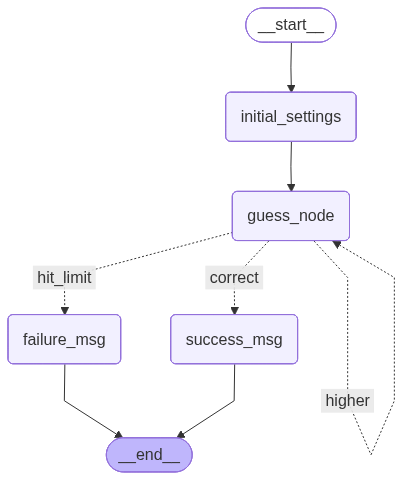

In [29]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
result = app.invoke(
    {
        "player_name": "Hong"
    }
)

result

{'player_name': 'Welcome to the High-Low Game, Hong',
 'guesses': [3, 18, 13, 8, 9, 7, 16, 4],
 'attempts': 8,
 'lower_bound': 1,
 'upper_bound': 20,
 'correct_number': 6,
 'message': 'Sorry, you failed to guess the correct number in 7 attempts!'}

In [32]:
result["message"]

'Sorry, you failed to guess the correct number in 7 attempts!'